Scanning trajectories:   0%|          | 593/1321000 [00:02<1:18:27, 280.50it/s]


SEGMENT violation in trajectory 600 at t=5


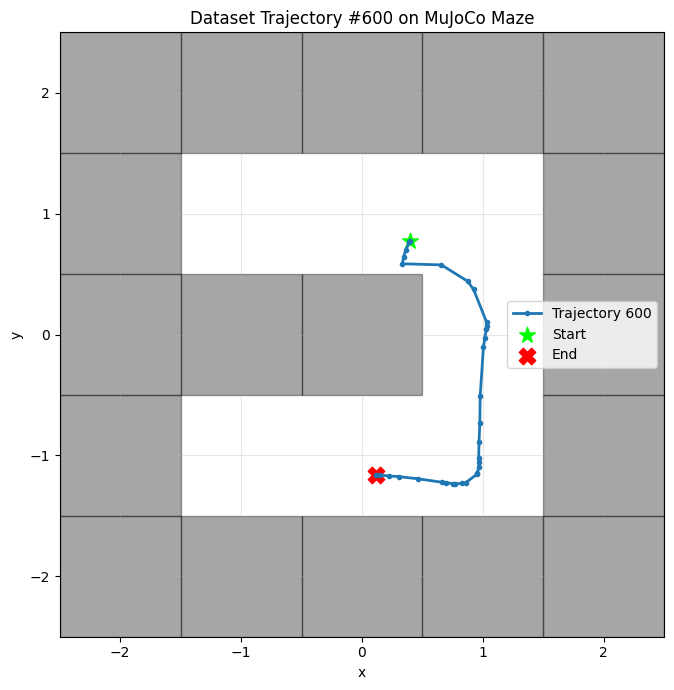

Scanning trajectories:   0%|          | 601/1321000 [02:03<593:32:41,  1.62s/it]


SEGMENT violation in trajectory 601 at t=3


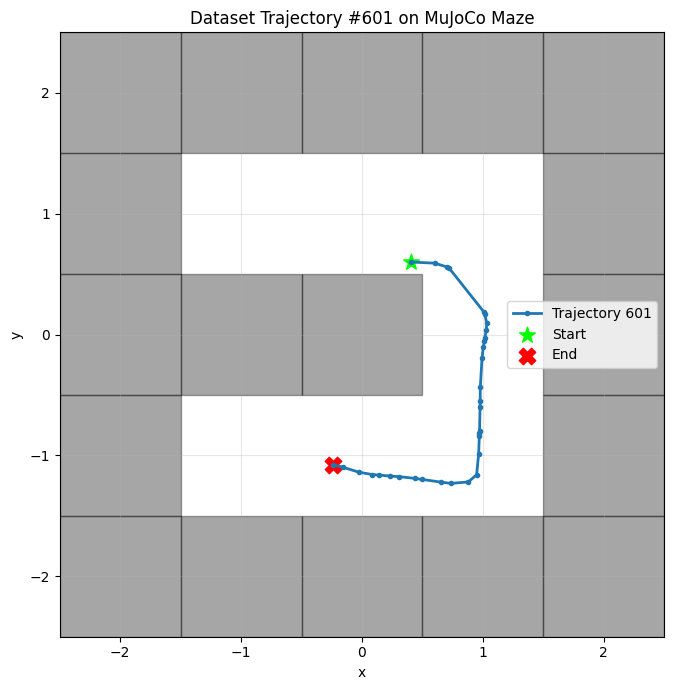

Scanning trajectories:   0%|          | 602/1321000 [02:05<602:40:49,  1.64s/it]


SEGMENT violation in trajectory 602 at t=8


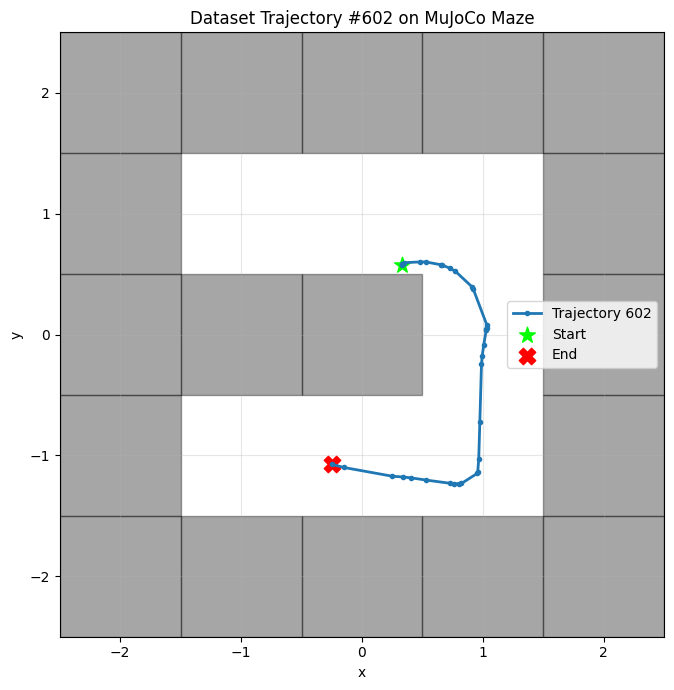


SEGMENT violation in trajectory 605 at t=6


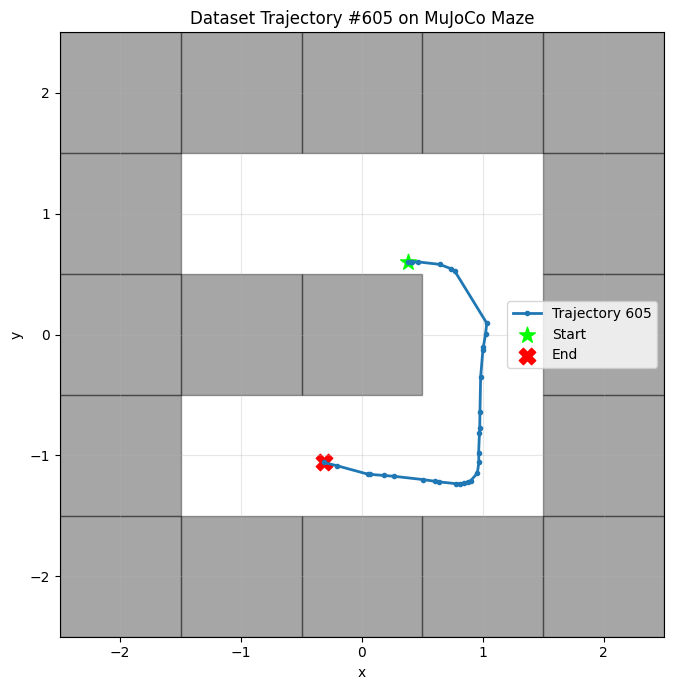


SEGMENT violation in trajectory 607 at t=7


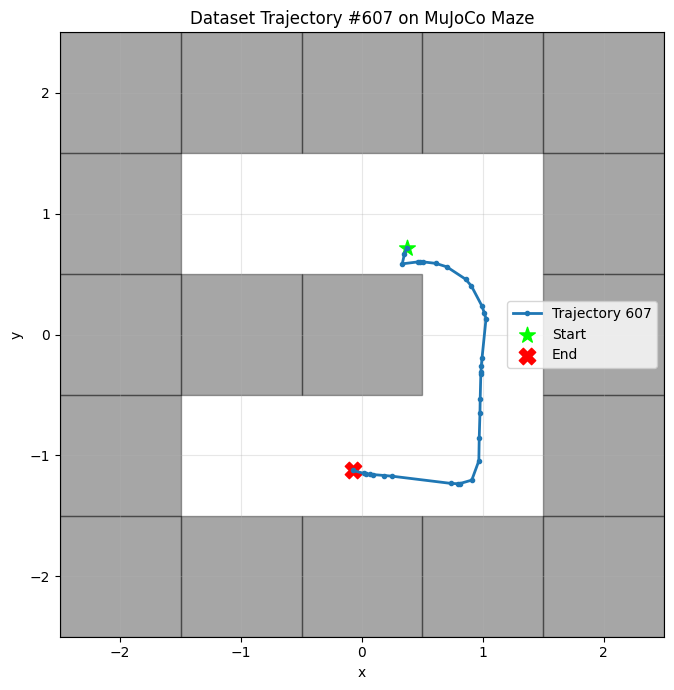


SEGMENT violation in trajectory 608 at t=7


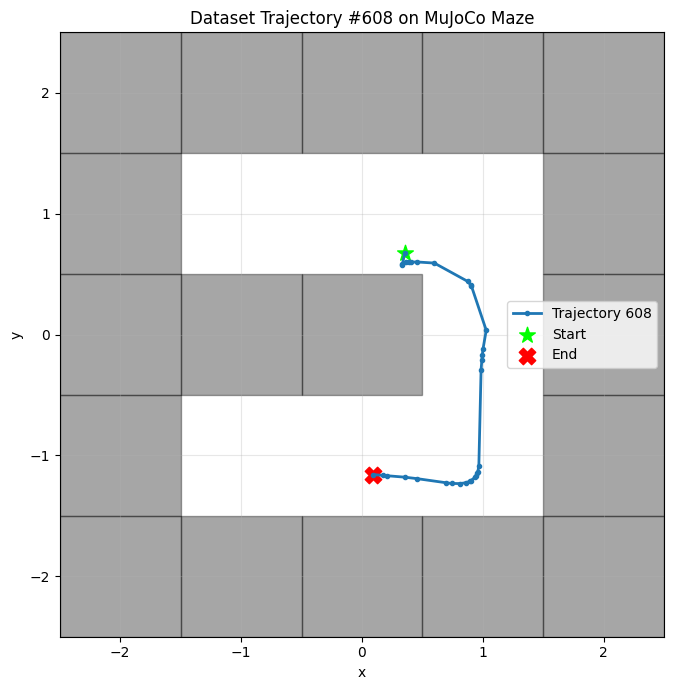


SEGMENT violation in trajectory 609 at t=8


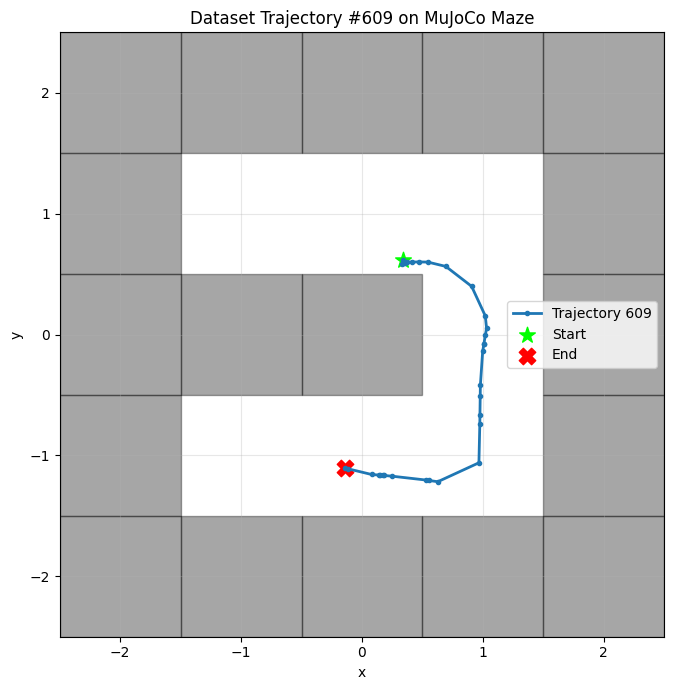

Scanning trajectories:   0%|          | 610/1321000 [02:24<642:40:02,  1.75s/it]


SEGMENT violation in trajectory 611 at t=7


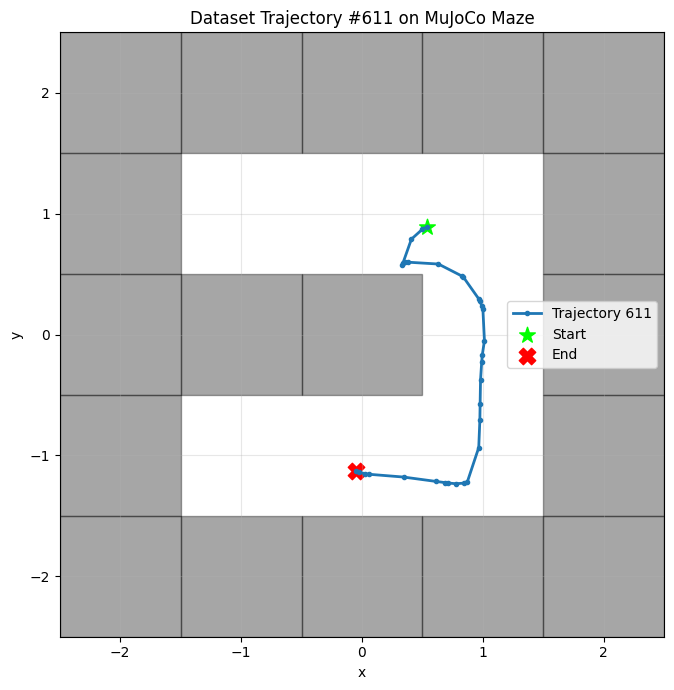

Scanning trajectories:   0%|          | 612/1321000 [02:26<631:04:14,  1.72s/it]


SEGMENT violation in trajectory 614 at t=3


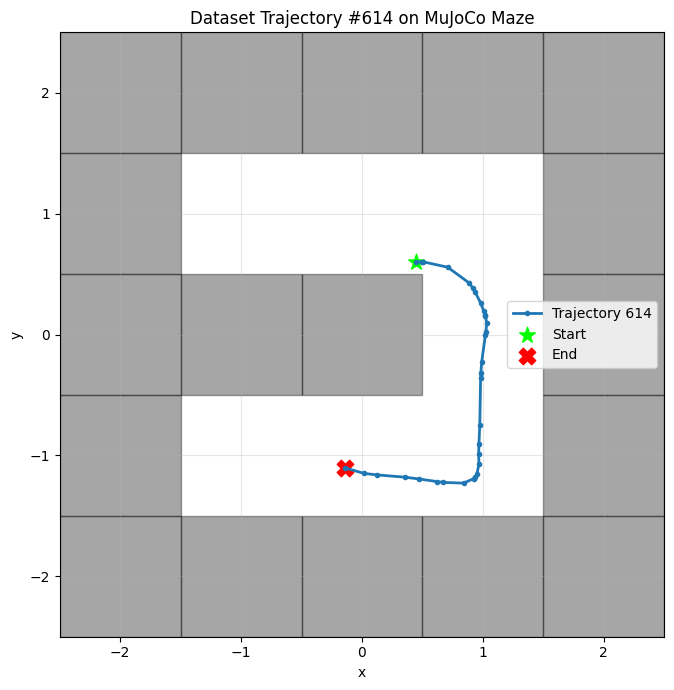


SEGMENT violation in trajectory 615 at t=3


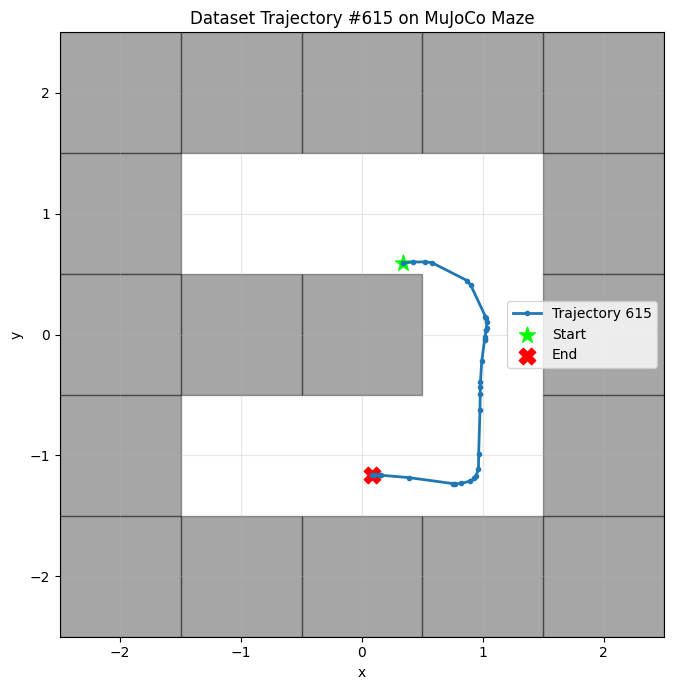


SEGMENT violation in trajectory 618 at t=10


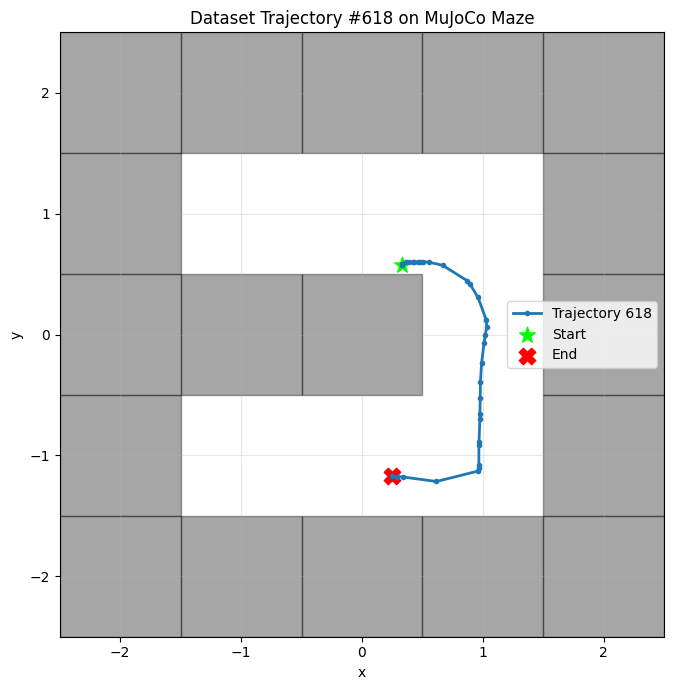


SEGMENT violation in trajectory 619 at t=9


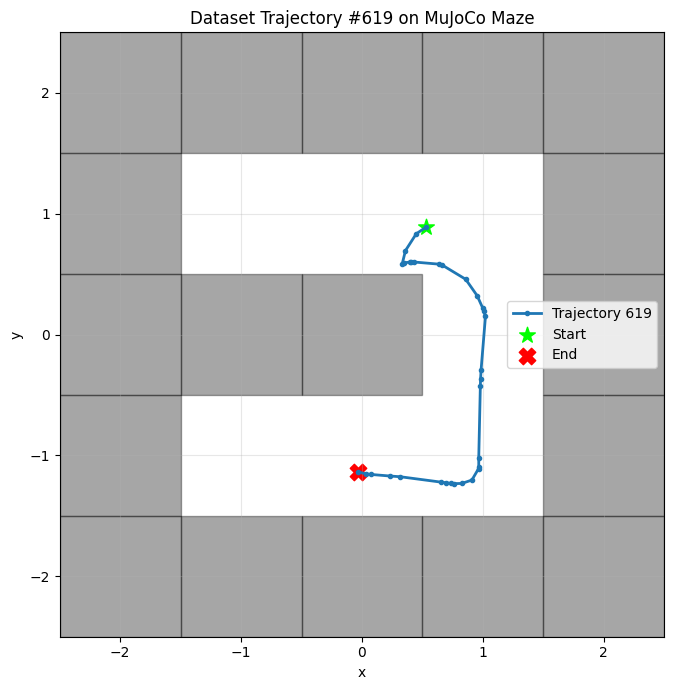

Scanning trajectories:   0%|          | 619/1321000 [05:10<184:14:03,  1.99it/s]

Stopping scan.

Scan complete
Total trajectories checked: 1321000
Trajectories with wall violations: 12
First 10 violations: [(600, 'SEGMENT', 5), (601, 'SEGMENT', 3), (602, 'SEGMENT', 8), (605, 'SEGMENT', 6), (607, 'SEGMENT', 7), (608, 'SEGMENT', 7), (609, 'SEGMENT', 8), (611, 'SEGMENT', 7), (614, 'SEGMENT', 3), (615, 'SEGMENT', 3)]


In [7]:
import numpy as np
from torch.utils.data import Dataset
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import mujoco
import minari

class MinariTrajectoryDatasetWithPseudoActions(Dataset):
    """
    Dataset for loading state (position) and skip-value trajectory sequences from Minari.

    Returned per-window sample shape: (H, 3)
      [:, 0:2] -> normalized positions (x, y)
      [:, 2]   -> normalized skip value (action)

    IMPORTANT: This dataset ALREADY implements positional augmentation!
    """

    def __init__(
        self, dataset_name="D4RL/pointmaze/umaze-v2", horizon=3, normalize=True,
        n_chunks_frac=0.5, alpha=3.0,
    ):
        self.horizon = horizon
        self.n_chunks_frac = n_chunks_frac
        self.alpha = alpha
        self.normalize_flag = normalize

        # Load dataset
        self.dataset = minari.load_dataset(dataset_name, download=True)

        # Containers for normalization
        self.state_trajectories = []
        self.skip_trajectories = []

        # TEMP arrays to gather skip/tau stats
        all_skips = []
        all_taus = []

        # ---------------------------------------------------------
        # Process episodes
        # ---------------------------------------------------------
        for episode in self.dataset:
            obs = episode.observations
            if isinstance(obs, dict):
                obs = obs["observation"]

            states = obs  # full env states, e.g. (x, y, vx, vy)
            T = len(states)
            positions = states[:, :2]

            # --- Dirichlet sampling ---
            n_chunks = max(1, int(self.n_chunks_frac * T))
            chunks = self._dirichlet_chunks(T, n_chunks=n_chunks, alpha=self.alpha)

            # --- Build skip_list ---
            skip_list = []
            tau = 0.0

            for chunk in chunks:
                tau_clamped = min(tau, T - 1)
                idx = int(np.floor(tau_clamped))
                delta_t = tau_clamped - idx

                if idx >= T - 1:
                    pos = positions[-1]
                else:
                    pos = positions[idx] + (positions[idx + 1] - positions[idx]) * delta_t

                skip_list.append((pos, chunk, tau_clamped))

                all_skips.append(chunk)
                all_taus.append(tau_clamped)

                tau += chunk

            self.state_trajectories.append(states)
            self.skip_trajectories.append(skip_list)

        # ---------------------------------------------------------
        # NORMALIZATION for positions (state) and skip (action)
        # ---------------------------------------------------------
        all_states = np.concatenate(self.state_trajectories, axis=0)  # (N, 4)
        all_pos = all_states[:, :2]

        # State = position (x, y)
        self.state_dim = 2
        self.action_dim = 1
        self.traj_dim = self.state_dim + self.action_dim  # 3

        if normalize:
            self.flat_mean = all_pos.mean(axis=0)
            self.flat_std = all_pos.std(axis=0) + 1e-8
        else:
            self.flat_mean = np.zeros(self.state_dim)
            self.flat_std = np.ones(self.state_dim)

        # Skip stats
        self.skip_mean = np.mean(all_skips)
        self.skip_std = np.std(all_skips) + 1e-8

        # Tau stats (not used directly in trajectory, but kept if needed)
        self.tau_mean = np.mean(all_taus)
        self.tau_std = np.std(all_taus) + 1e-8

        # Combined mean/std over full trajectory vector [x, y, skip]
        self.mean = np.zeros(self.traj_dim, dtype=np.float32)
        self.std = np.ones(self.traj_dim, dtype=np.float32)

        self.mean[:self.state_dim] = self.flat_mean
        self.std[:self.state_dim] = self.flat_std
        self.mean[self.state_dim] = self.skip_mean
        self.std[self.state_dim] = self.skip_std

        # ---------------------------------------------------------
        # Build horizon windows
        # ---------------------------------------------------------
        self.indices = []
        for traj_idx, skip_list in enumerate(self.skip_trajectories):
            S = len(skip_list)
            if S >= self.horizon:
                for t in range(S - self.horizon + 1):
                    self.indices.append((traj_idx, t))

    # ---------------------------------------------------------
    def normalize(self, x):
        """Normalize positions (x,y)."""
        return (x - self.flat_mean) / self.flat_std

    def denormalize(self, x):
        """Denormalize positions (x,y)."""
        return x * self.flat_std + self.flat_mean

    # ---------------------------------------------------------
    @staticmethod
    def _dirichlet_chunks(total_T, n_chunks, alpha):
        weights = np.random.dirichlet([alpha] * n_chunks)
        return weights * total_T

    # ---------------------------------------------------------
    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        traj_idx, start = self.indices[idx]
        skip_list = self.skip_trajectories[traj_idx]
        window = skip_list[start:start + self.horizon]

        positions = np.array([p for (p, c, tau) in window], dtype=np.float32)
        skip_vals = np.array([c for (p, c, tau) in window], dtype=np.float32)
        tau_vals = np.array([tau for (p, c, tau) in window], dtype=np.float32)  # not used downstream

        # ---- Apply normalization ----
        positions = self.normalize(positions)
        skip_vals = (skip_vals - self.skip_mean) / self.skip_std
        # tau_vals_norm = (tau_vals - self.tau_mean) / self.tau_std  # computed but unused here

        # ---- Build final trajectory [H, 3] = [x_norm, y_norm, skip_norm]
        state = np.zeros((self.horizon, self.traj_dim), dtype=np.float32)
        state[:, :self.state_dim] = positions
        state[:, self.state_dim] = skip_vals  # single action channel

        return torch.FloatTensor(state)

class OfflineSkipDataset(Dataset):
    """
    Loads precomputed, normalized windows (N, horizon, 3)
    from an .npz archive that also contains normalization statistics.

    Mirrors exactly the attributes of MinariTrajectoryDatasetIndependentSkips:
        - state_dim = 2
        - action_dim = 1
        - traj_dim = 3
        - pos_mean, pos_std
        - flat_mean, flat_std
        - skip_mean, skip_std
        - mean, std  (full 3-dim stats)
    """

    def __init__(self, file_path, horizon=32):
        archive = np.load(file_path)

        # -------------------------------------------------------
        # Load normalized trajectory data
        # -------------------------------------------------------
        data = archive["data"]  # (N, H, 3)
        assert data.ndim == 3 and data.shape[1] == horizon

        self.data = torch.from_numpy(data).float()
        self.horizon = horizon

        # Exactly match MinariIndependent dims
        self.state_dim = 2          # (x, y)
        self.action_dim = 1         # skip
        self.traj_dim = 3           # 2 + 1

        # -------------------------------------------------------
        # Load same normalization fields as the on-the-fly dataset
        # -------------------------------------------------------

        # Position normalization
        self.pos_mean = archive["flat_mean"].astype(np.float32)  # (2,)
        self.pos_std  = archive["flat_std"].astype(np.float32)   # (2,)

        # IMPORTANT: aliases so planner code works
        self.flat_mean = self.pos_mean
        self.flat_std  = self.pos_std

        # Skip normalization
        self.skip_mean = float(archive["skip_mean"])
        self.skip_std  = float(archive["skip_std"])

        # Full 3-d normalization (for denorm in planner)
        self.mean = archive["full_mean"].astype(np.float32)      # (3,)
        self.std  = archive["full_std"].astype(np.float32)       # (3,)

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        """
        Returns: (H, 3) tensor:
            [:,0:2] normalized positions
            [:,2]   normalized skip
        """
        return self.data[idx]
   
   
   

def plot_dataset_traj_on_mujoco_maze(traj_xy, idx, mj_model):
    """
    traj_xy: (T, 2) array of (x, y) positions
    idx: trajectory index (for title)
    mj_model: MuJoCo model (env.model)
    """

    fig, ax = plt.subplots(figsize=(7, 7))

    # ===========================================================
    # 1) Plot trajectory
    # ===========================================================
    ax.plot(
        traj_xy[:, 0],
        traj_xy[:, 1],
        "-o",
        linewidth=2,
        markersize=3,
        color="tab:blue",
        label=f"Trajectory {idx}"
    )

    ax.scatter(
        traj_xy[0, 0],
        traj_xy[0, 1],
        s=140,
        marker="*",
        color="lime",
        label="Start"
    )

    ax.scatter(
        traj_xy[-1, 0],
        traj_xy[-1, 1],
        s=140,
        marker="X",
        color="red",
        label="End"
    )

    # ===========================================================
    # 2) Draw MuJoCo maze walls (all geoms named "block")
    # ===========================================================
    for geom_id in range(mj_model.ngeom):
        name = mujoco.mj_id2name(
            mj_model,
            mujoco.mjtObj.mjOBJ_GEOM,
            geom_id
        )

        if name is None:
            continue

        # PointMaze walls always contain "block"
        if "block" not in name.lower():
            continue

        pos = mj_model.geom_pos[geom_id]      # (x, y, z)
        size = mj_model.geom_size[geom_id]    # (hx, hy, hz)

        cx, cy = pos[0], pos[1]
        hx, hy = size[0], size[1]

        rect = Rectangle(
            (cx - hx, cy - hy),
            2 * hx,
            2 * hy,
            color="black",
            alpha=0.35,
            zorder=0
        )

        ax.add_patch(rect)

    # ===========================================================
    # 3) Final styling
    # ===========================================================
    ax.set_title(f"Dataset Trajectory #{idx} on MuJoCo Maze")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal", "box")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")

    # Maze bounds (PointMaze standard)
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)

    plt.tight_layout()
    plt.show()
   
   
   
    
# Each wall is (xmin, xmax, ymin, ymax)
WALLS = [
    # Outer boundary
    (-2.5,  2.5,  1.5,  2.5),   # top
    (-2.5,  2.5, -2.5, -1.5),  # bottom
    (-2.5, -1.5, -2.5,  2.5),  # left
    ( 1.5,  2.5, -2.5,  2.5),  # right

    # Center block
    (-0.5,  0.8, -0.2,  0.5),
]


def point_in_any_wall(x, y, walls):
    for xmin, xmax, ymin, ymax in walls:
        if xmin <= x <= xmax and ymin <= y <= ymax:
            return True
    return False

def segment_hits_wall(p0, p1, walls, steps=100):
    for s in range(steps + 1):
        t = s / steps
        x = (1 - t) * p0[0] + t * p1[0]
        y = (1 - t) * p0[1] + t * p1[1]
        if point_in_any_wall(x, y, walls):
            return True
    return False


def scan_dataset_for_wall_violations(dataset, walls, mj_model):
    bad_trajs = []

    data = dataset.data.cpu().numpy()   # (N, T, D)

    for i in tqdm(range(len(data)), desc="Scanning trajectories"):
        traj = data[i, :, :2] * dataset.flat_std + dataset.flat_mean

        violated = False
        violation_type = None
        violation_t = None

        # 1. Point-wise check
        for t in range(len(traj)):
            if point_in_any_wall(traj[t][0], traj[t][1], walls):
                violated = True
                violation_type = "POINT"
                violation_t = t
                break

        # 2. Segment-wise check
        if not violated:
            for t in range(len(traj) - 1):
                if segment_hits_wall(traj[t], traj[t+1], walls):
                    violated = True
                    violation_type = "SEGMENT"
                    violation_t = t
                    break

        # ---- INTERACTIVE PAUSE + MAZE PLOT ----
        if violated:
            print(f"\n{violation_type} violation in trajectory {i} at t={violation_t}")
            bad_trajs.append((i, violation_type, violation_t))

            plot_dataset_traj_on_mujoco_maze(traj, i, mj_model)

            user = input("Continue scanning? (y/n): ").strip().lower()
            if user != "y":
                print("Stopping scan.")
                break

    print(f"\nScan complete")
    print(f"Total trajectories checked: {len(data)}")
    print(f"Trajectories with wall violations: {len(bad_trajs)}")

    return bad_trajs


dataset = MinariTrajectoryDatasetWithPseudoActions(
    "D4RL/pointmaze/umaze-v2", horizon=32, n_chunks_frac= 0.5
)

env = dataset.dataset.recover_environment()

def unwrap_env(env):
    while hasattr(env, "env"):
        env = env.env
    return env

env = unwrap_env(env)

mj_model = env.model
mj_data = env.data


minari_dataset = OfflineSkipDataset(
    "offline_umaze_independent_skips.npz",
    horizon=32
)

violations = scan_dataset_for_wall_violations(
    dataset=minari_dataset,
    walls=WALLS,
    mj_model=mj_model
)

# Print first few
print("First 10 violations:", violations[:10])